# IE333: Data Science and Analytics
# Project Report: Exploratory Data Analysis and Classical Modeling for Time Series Data

**Dataset:** Monthly International Airline Passengers (1949–1960)

**Objective:** Forecast monthly airline passenger numbers using historical data, applying EDA and classical time series models.

---


## Chapter 1: Introduction

### 1.1 Problem Statement

The aviation industry relies heavily on accurate demand forecasting to optimize capacity planning, scheduling, and revenue management. In this project, we aim to **forecast monthly international airline passenger numbers** using historical data spanning from January 1949 to December 1960.

We will apply classical time series modeling techniques — specifically ARIMA and regression-based approaches (polynomial + Fourier features) — to capture the underlying trend and seasonal patterns in the data, and evaluate which model provides superior forecasting performance.

### 1.2 Dataset Overview

| Property | Details |
|----------|---------|
| **Source** | Box, G. E. P., Jenkins, G. M. and Reinsel, G. C. (1976) *Time Series Analysis, Forecasting and Control* |
| **Repository** | [jbrownlee/Datasets on GitHub](https://github.com/jbrownlee/Datasets) |
| **Variables** | `Month` (date), `Passengers` (thousands of international airline passengers) |
| **Time Range** | January 1949 – December 1960 (144 monthly observations) |
| **Frequency** | Monthly |

### 1.3 Key Questions to Answer

1. Does the data exhibit a trend? If so, is it linear or nonlinear?
2. Is there seasonality in the data? What is its period?
3. Is the variance constant over time, or does it grow with the level of the series?
4. Which classical model — ARIMA or Regression with Fourier features, or Exponential Smoothing (Holt-Winters ) — provides more accurate forecasts?
5. How do the models compare on RMSE, MAPE, and R²?


## Chapter 2: Data Collection & Preprocessing

### 2.1 Data Loading


In [25]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Statsmodels for time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARIMA
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully.")


All libraries imported successfully.


In [27]:
# Load the dataset
df = pd.read_csv('airline-passengers.csv')

# Display basic info
print("=== First 5 Rows ===")
print(df.head())
print(f"\n=== Shape: {df.shape} ===")
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Last 5 Rows ===")
print(df.tail())


=== First 5 Rows ===
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

=== Shape: (144, 2) ===

=== Data Types ===
Month         object
Passengers     int64
dtype: object

=== Last 5 Rows ===
       Month  Passengers
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432


### 2.2 Data Cleaning


In [28]:
# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Set frequency explicitly to Monthly Start
df.index.freq = 'MS'

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Check for duplicates
print(f"\n=== Duplicate Rows: {df.duplicated().sum()} ===")

# Check for outliers using IQR method
Q1 = df['Passengers'].quantile(0.25)
Q3 = df['Passengers'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Passengers'] < lower_bound) | (df['Passengers'] > upper_bound)]
print(f"\n=== Outliers (IQR Method) ===")
print(f"Lower bound: {lower_bound:.1f}, Upper bound: {upper_bound:.1f}")
print(f"Number of outliers: {len(outliers)}")
if len(outliers) > 0:
    print(outliers)
else:
    print("No outliers detected.")

print("\n=== Data Info After Cleaning ===")
print(df.info())


=== Missing Values ===
Passengers    0
dtype: int64

=== Duplicate Rows: 26 ===

=== Outliers (IQR Method) ===
Lower bound: -90.8, Upper bound: 631.2
Number of outliers: 0
No outliers detected.

=== Data Info After Cleaning ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


### 2.3 Feature Engineering


In [29]:
# Create time-based features for regression modeling later
df['Year'] = df.index.year
df['Month_Num'] = df.index.month
df['Quarter'] = df.index.quarter
df['Day_of_Year'] = df.index.dayofyear
df['Time_Index'] = np.arange(len(df))  # linear time index (0, 1, 2, ...)

print("=== New Features Created ===")
print(df.head(12))


=== New Features Created ===
            Passengers  Year  Month_Num  Quarter  Day_of_Year  Time_Index
Month                                                                    
1949-01-01         112  1949          1        1            1           0
1949-02-01         118  1949          2        1           32           1
1949-03-01         132  1949          3        1           60           2
1949-04-01         129  1949          4        2           91           3
1949-05-01         121  1949          5        2          121           4
1949-06-01         135  1949          6        2          152           5
1949-07-01         148  1949          7        3          182           6
1949-08-01         148  1949          8        3          213           7
1949-09-01         136  1949          9        3          244           8
1949-10-01         119  1949         10        4          274           9
1949-11-01         104  1949         11        4          305          10
1949-12-0

### 2.4 Data Splitting

We use an **80-20 train-test split**. Since this is time series data, we split chronologically (the last ~29 months become the test set).


Training set: 1949-01 to 1958-07 (115 observations)
Test set:     1958-08 to 1960-12 (29 observations)


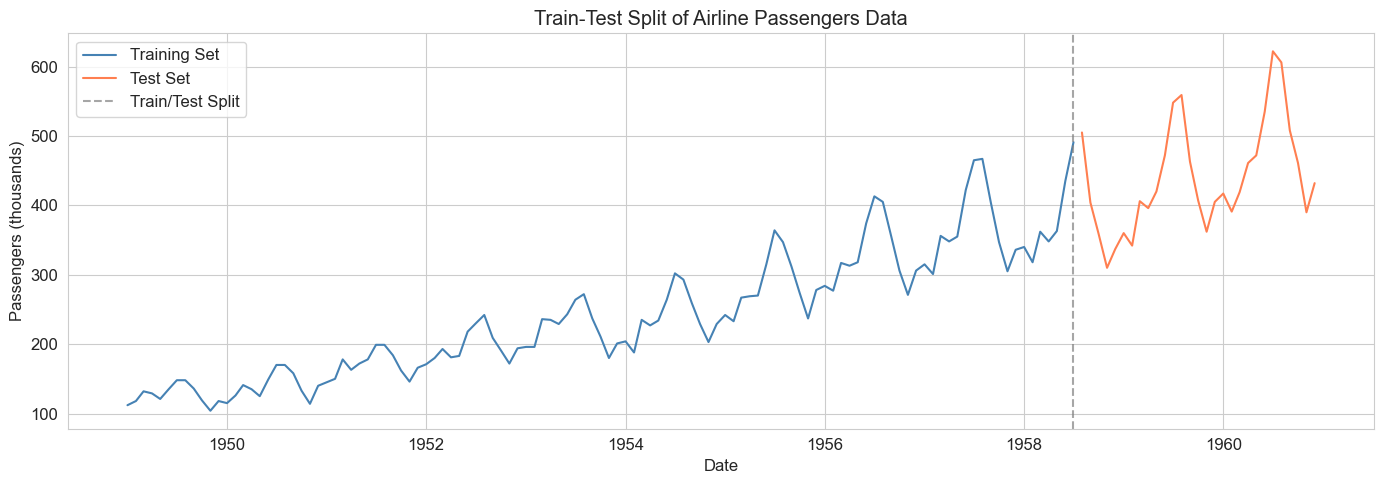

In [30]:
# 80-20 chronological split
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Training set: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')} ({len(train)} observations)")
print(f"Test set:     {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')} ({len(test)} observations)")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train['Passengers'], label='Training Set', color='steelblue')
ax.plot(test.index, test['Passengers'], label='Test Set', color='coral')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.7, label='Train/Test Split')
ax.set_title('Train-Test Split of Airline Passengers Data')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()


## Chapter 3: Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics


In [31]:
# Comprehensive descriptive statistics
desc = df['Passengers'].describe()
skewness = df['Passengers'].skew()
kurtosis = df['Passengers'].kurtosis()

print("=== Descriptive Statistics ===")
print(desc)
print(f"\nSkewness:  {skewness:.4f}")
print(f"Kurtosis:  {kurtosis:.4f}")
print(f"Variance:  {df['Passengers'].var():.2f}")
print(f"\nInterpretation:")
print(f"- Skewness > 0 indicates a right-skewed distribution (more low values, fewer high values).")
print(f"- The range is {desc['max'] - desc['min']:.0f} passengers, showing substantial variation.")


=== Descriptive Statistics ===
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64

Skewness:  0.5832
Kurtosis:  -0.3649
Variance:  14391.92

Interpretation:
- Skewness > 0 indicates a right-skewed distribution (more low values, fewer high values).
- The range is 518 passengers, showing substantial variation.


In [32]:
# Monthly statistics to see seasonal patterns
monthly_stats = df.groupby('Month_Num')['Passengers'].agg(['mean', 'std', 'min', 'max'])
monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print("=== Monthly Statistics ===")
print(monthly_stats.round(1))


=== Monthly Statistics ===
      mean    std  min  max
Jan  241.8  101.0  112  417
Feb  235.0   89.6  118  391
Mar  270.2  100.6  132  419
Apr  267.1  107.4  129  461
May  271.8  114.7  121  472
Jun  311.7  134.2  135  535
Jul  351.3  156.8  148  622
Aug  351.1  155.8  148  606
Sep  302.4  124.0  136  508
Oct  266.6  110.7  119  461
Nov  232.8   95.2  104  390
Dec  261.8  103.1  118  432


### 3.2 Time Series Decomposition


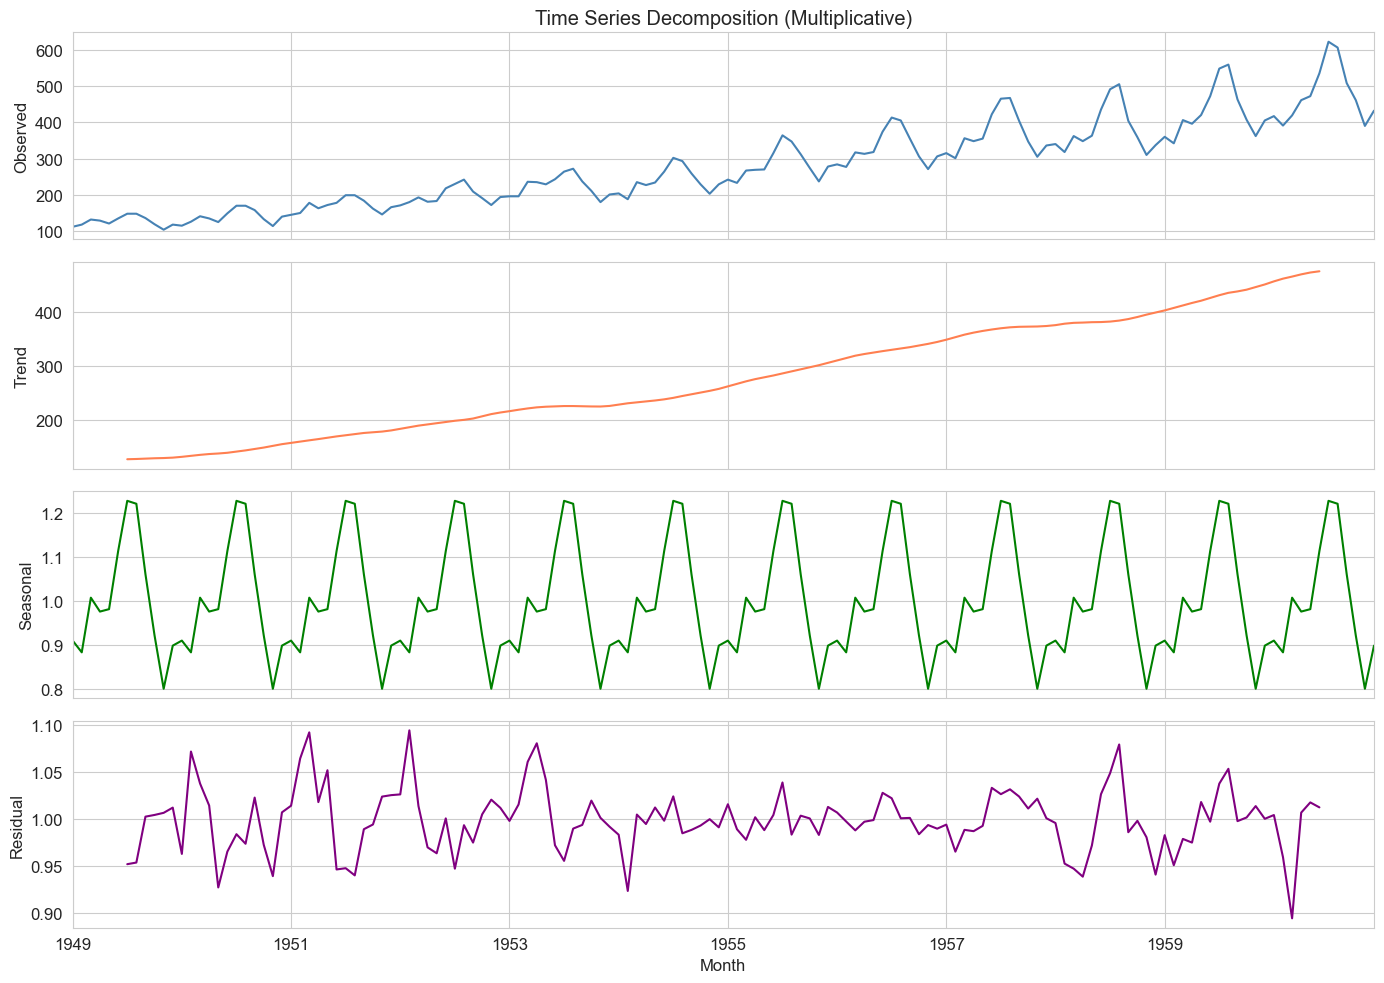

Observation: The multiplicative model is appropriate because the seasonal fluctuations
grow proportionally with the trend — peaks get higher and troughs get deeper over time.


In [33]:
# Multiplicative decomposition (appropriate because variance grows with level)
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition (Multiplicative)')

decomposition.trend.plot(ax=axes[1], color='coral')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='purple')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print("Observation: The multiplicative model is appropriate because the seasonal fluctuations")
print("grow proportionally with the trend — peaks get higher and troughs get deeper over time.")


### 3.3 Visualizations


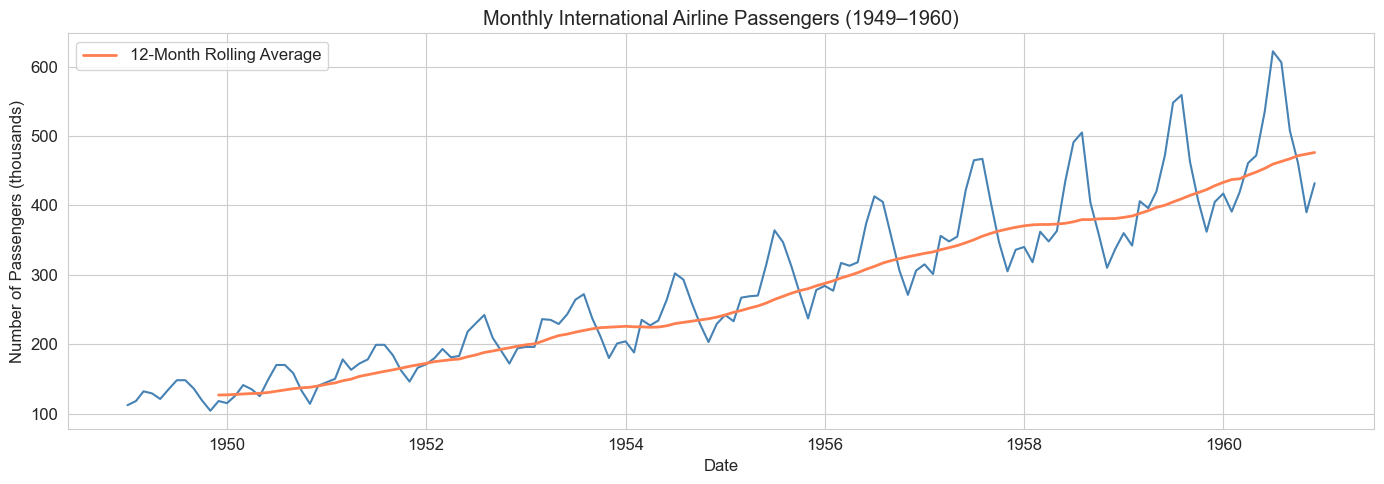

In [34]:
# VISUALIZATION 1: Line Plot — Trend Over Time
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Passengers'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly International Airline Passengers (1949–1960)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Passengers (thousands)')

# Add a rolling average for trend
rolling_avg = df['Passengers'].rolling(window=12).mean()
ax.plot(df.index, rolling_avg, color='coral', linewidth=2, label='12-Month Rolling Average')
ax.legend()
plt.tight_layout()
plt.show()


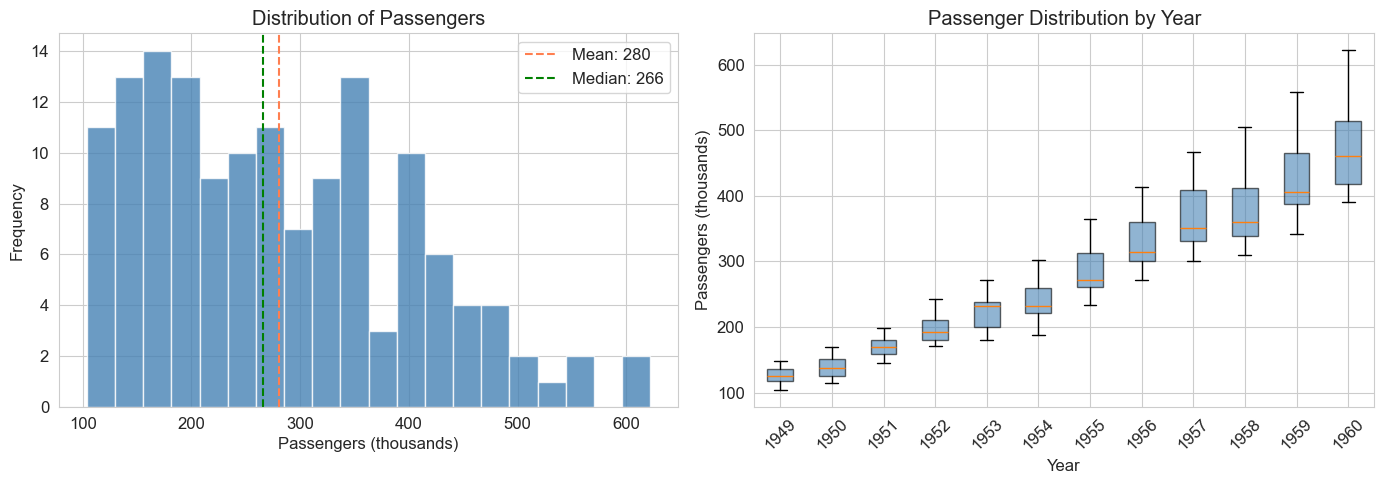

In [35]:
# VISUALIZATION 2: Histogram + Box Plot (Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Passengers'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Passengers')
axes[0].set_xlabel('Passengers (thousands)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Passengers'].mean(), color='coral', linestyle='--', label=f"Mean: {df['Passengers'].mean():.0f}")
axes[0].axvline(df['Passengers'].median(), color='green', linestyle='--', label=f"Median: {df['Passengers'].median():.0f}")
axes[0].legend()

# Box plot by year
yearly_data = [df[df['Year'] == y]['Passengers'].values for y in df['Year'].unique()]
bp = axes[1].boxplot(yearly_data, labels=df['Year'].unique(), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].set_title('Passenger Distribution by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Passengers (thousands)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


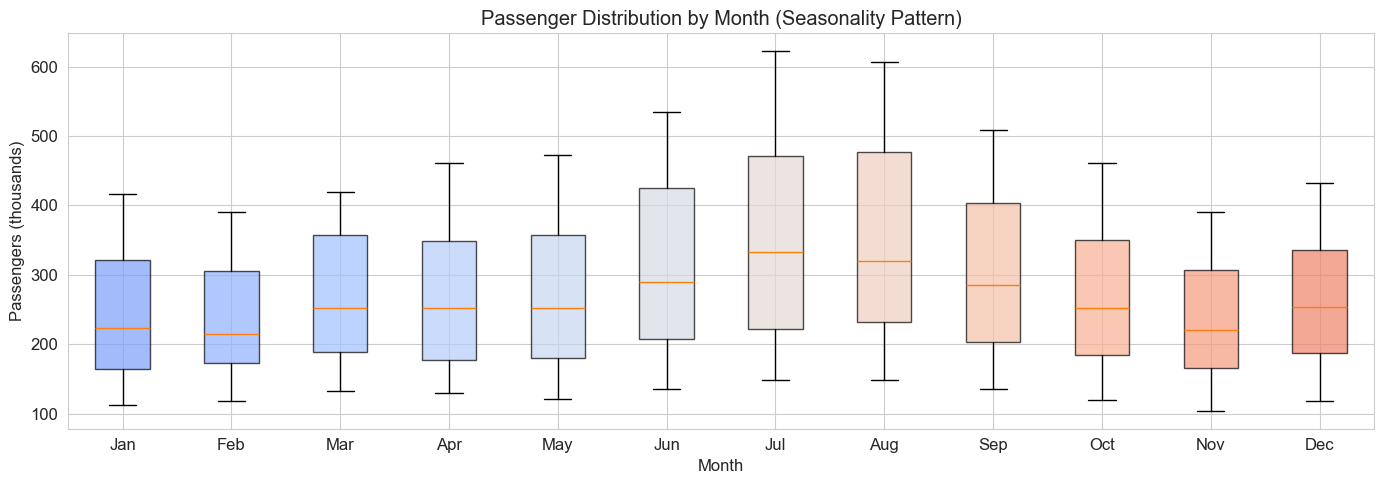

Observation: Clear seasonality — July and August have the highest passenger counts (summer travel),
while November and February have the lowest.


In [36]:
# VISUALIZATION 3: Seasonal Box Plot
fig, ax = plt.subplots(figsize=(14, 5))
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = [df[df['Month_Num'] == m]['Passengers'].values for m in range(1, 13)]
bp = ax.boxplot(monthly_data, labels=month_labels, patch_artist=True)
colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Passenger Distribution by Month (Seasonality Pattern)')
ax.set_xlabel('Month')
ax.set_ylabel('Passengers (thousands)')
plt.tight_layout()
plt.show()

print("Observation: Clear seasonality — July and August have the highest passenger counts (summer travel),")
print("while November and February have the lowest.")


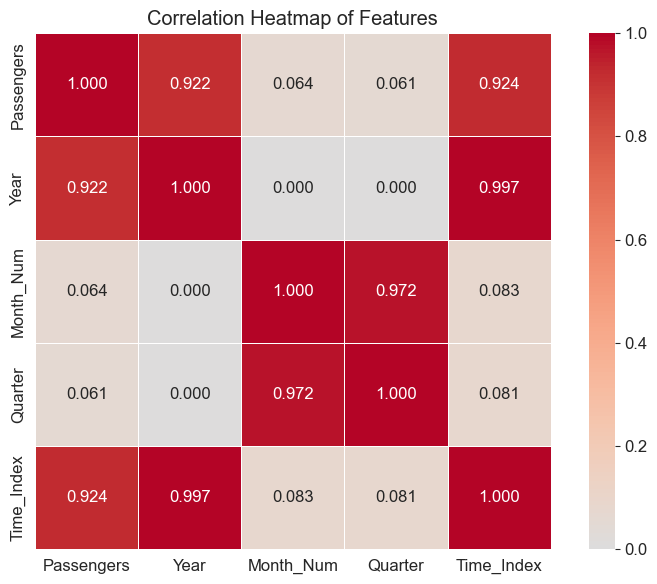

Observation: Passengers is strongly correlated with Year/Time_Index (trend effect).
Month_Num has low correlation because seasonality is cyclical, not linear.


In [37]:
# VISUALIZATION 4: Correlation Heatmap
corr_features = df[['Passengers', 'Year', 'Month_Num', 'Quarter', 'Time_Index']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_features, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

print("Observation: Passengers is strongly correlated with Year/Time_Index (trend effect).")
print("Month_Num has low correlation because seasonality is cyclical, not linear.")


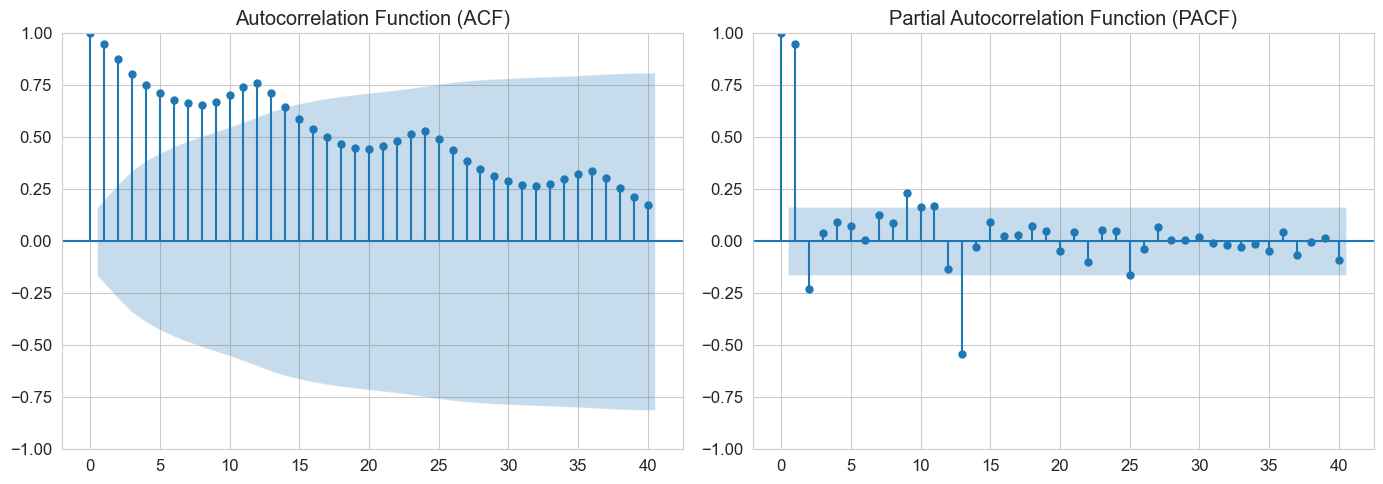

Observation: The ACF shows slow decay (indicating trend) and periodic spikes at lags 12, 24, 36
(confirming monthly seasonality with period=12).


In [38]:
# VISUALIZATION 5: ACF and PACF plots (important for ARIMA)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Passengers'], lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

print("Observation: The ACF shows slow decay (indicating trend) and periodic spikes at lags 12, 24, 36")
print("(confirming monthly seasonality with period=12).")


In [39]:
# Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(df['Passengers'], autolag='AIC')

print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Lags Used:     {adf_result[2]}")
print(f"Observations:  {adf_result[3]}")
print(f"\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series IS stationary (p < 0.05). Reject the null hypothesis.")
else:
    print("\nConclusion: The series is NOT stationary (p >= 0.05). Fail to reject the null hypothesis.")
    print("Differencing will be needed before applying ARIMA.")


=== Augmented Dickey-Fuller Test ===
ADF Statistic: 0.8154
p-value:       0.9919
Lags Used:     13
Observations:  130

Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788

Conclusion: The series is NOT stationary (p >= 0.05). Fail to reject the null hypothesis.
Differencing will be needed before applying ARIMA.


## Chapter 4: Modeling

### 4.1 Model 1: ARIMA

**ARIMA** stands for AutoRegressive Integrated Moving Average. The three parameters are:
- **p** (AutoRegressive order): Number of lag observations included in the model
- **d** (Differencing order): Number of times the data is differenced to achieve stationarity
- **q** (Moving Average order): Size of the moving average window

We will also explore **SARIMA** (Seasonal ARIMA) since our data has clear seasonality.


In [40]:
# Use auto_arima to find the best ARIMA parameters
# seasonal=True enables SARIMA to capture the 12-month seasonality
auto_model = pm.auto_arima(
    train['Passengers'],
    seasonal=True,
    m=12,                  # seasonal period = 12 months
    d=None,                # let auto_arima determine d
    D=None,                # let auto_arima determine seasonal D
    trace=True,            # print search progress
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2
)

print("\n=== Best ARIMA Model ===")
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=757.714, Time=0.45 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=757.826, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=755.750, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=756.380, Time=0.10 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=755.499, Time=0.03 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=755.982, Time=0.08 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=757.649, Time=0.15 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=756.771, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=756.022, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=756.011, Time=0.03 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=757.976, Time=0.09 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=757.438, Time=0.09 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.242 seconds

=== Best ARIMA Model ===
                                     SARIMAX Results         

In [41]:
# Fit the best ARIMA/SARIMA model on training data
best_order = auto_model.order
best_seasonal = auto_model.seasonal_order

print(f"Best order (p,d,q): {best_order}")
print(f"Best seasonal order (P,D,Q,m): {best_seasonal}")

# Generate forecasts for the test period
n_forecast = len(test)
arima_forecast, arima_conf_int = auto_model.predict(
    n_periods=n_forecast,
    return_conf_int=True,
    alpha=0.05  # 95% confidence interval
)

# Create a Series with the correct index
arima_forecast = pd.Series(arima_forecast, index=test.index)
arima_conf_lower = pd.Series(arima_conf_int[:, 0], index=test.index)
arima_conf_upper = pd.Series(arima_conf_int[:, 1], index=test.index)

print(f"\nForecasted {n_forecast} periods.")


Best order (p,d,q): (1, 1, 0)
Best seasonal order (P,D,Q,m): (0, 1, 0, 12)

Forecasted 29 periods.


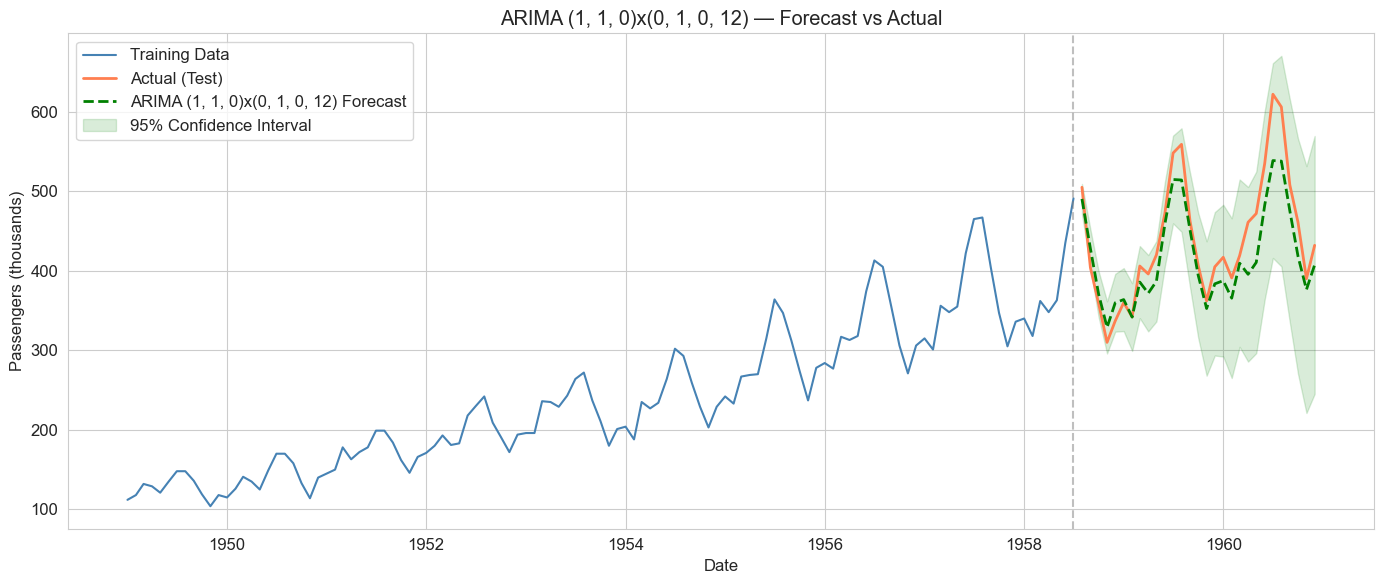

In [42]:
# ARIMA Forecast Visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot training data
ax.plot(train.index, train['Passengers'], label='Training Data', color='steelblue')

# Plot actual test data
ax.plot(test.index, test['Passengers'], label='Actual (Test)', color='coral', linewidth=2)

# Plot ARIMA forecast
ax.plot(test.index, arima_forecast, label=f'ARIMA {best_order}x{best_seasonal} Forecast',
        color='green', linewidth=2, linestyle='--')

# Plot confidence interval
ax.fill_between(test.index, arima_conf_lower, arima_conf_upper,
                color='green', alpha=0.15, label='95% Confidence Interval')

ax.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'ARIMA {best_order}x{best_seasonal} — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.2 Model 2: Regression-Based (Polynomial + Fourier Features)

We combine:
- **Polynomial regression** to capture the nonlinear trend
- **Fourier features** (sine/cosine terms) to capture the seasonal pattern

This approach is powerful because Fourier terms can approximate any periodic pattern.


In [43]:
# Build regression features
def create_regression_features(data, n_harmonics=4, poly_degree=2):
    """
    Create features for regression model:
    - Polynomial terms for trend
    - Fourier (sine/cosine) terms for seasonality
    """
    X = pd.DataFrame(index=data.index)

    # Time index (for trend)
    t = data['Time_Index'].values

    # Polynomial features for trend
    for degree in range(1, poly_degree + 1):
        X[f'time_poly_{degree}'] = t ** degree

    # Fourier features for seasonality (period = 12 months)
    period = 12
    for k in range(1, n_harmonics + 1):
        X[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        X[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)

    return X

# Create features for train and test
n_harmonics = 4   # number of Fourier harmonics
poly_degree = 2   # polynomial degree for trend

X_train = create_regression_features(train, n_harmonics=n_harmonics, poly_degree=poly_degree)
X_test = create_regression_features(test, n_harmonics=n_harmonics, poly_degree=poly_degree)
y_train = train['Passengers']
y_test = test['Passengers']

print("=== Regression Features ===")
print(f"Number of features: {X_train.shape[1]}")
print(f"Features: {list(X_train.columns)}")
print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\n=== Feature Sample (first 5 rows) ===")
print(X_train.head())


=== Regression Features ===
Number of features: 10
Features: ['time_poly_1', 'time_poly_2', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3', 'sin_4', 'cos_4']

Training samples: 115
Test samples:     29

=== Feature Sample (first 5 rows) ===
            time_poly_1  time_poly_2     sin_1         cos_1         sin_2  \
Month                                                                        
1949-01-01            0            0  0.000000  1.000000e+00  0.000000e+00   
1949-02-01            1            1  0.500000  8.660254e-01  8.660254e-01   
1949-03-01            2            4  0.866025  5.000000e-01  8.660254e-01   
1949-04-01            3            9  1.000000  6.123234e-17  1.224647e-16   
1949-05-01            4           16  0.866025 -5.000000e-01 -8.660254e-01   

            cos_2         sin_3         cos_3         sin_4  cos_4  
Month                                                               
1949-01-01    1.0  0.000000e+00  1.000000e+00  0.000000e+00    1.0  

In [44]:
# Fit Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predictions
reg_train_pred = reg_model.predict(X_train)
reg_test_pred = reg_model.predict(X_test)
reg_forecast = pd.Series(reg_test_pred, index=test.index)

# Feature importance (coefficients)
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': reg_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("=== Model Coefficients (Feature Importance) ===")
print(coeff_df.to_string(index=False))
print(f"\nIntercept: {reg_model.intercept_:.4f}")
print(f"R² on Training Set: {r2_score(y_train, reg_train_pred):.4f}")


=== Model Coefficients (Feature Importance) ===
    Feature  Coefficient
      cos_1   -35.830123
      cos_2    15.237450
      sin_2    13.266634
      sin_4    -7.760520
      sin_3    -6.170613
      sin_1     4.872763
      cos_3    -3.959349
      cos_4     2.620738
time_poly_1     1.449854
time_poly_2     0.009228

Intercept: 116.8950
R² on Training Set: 0.9628


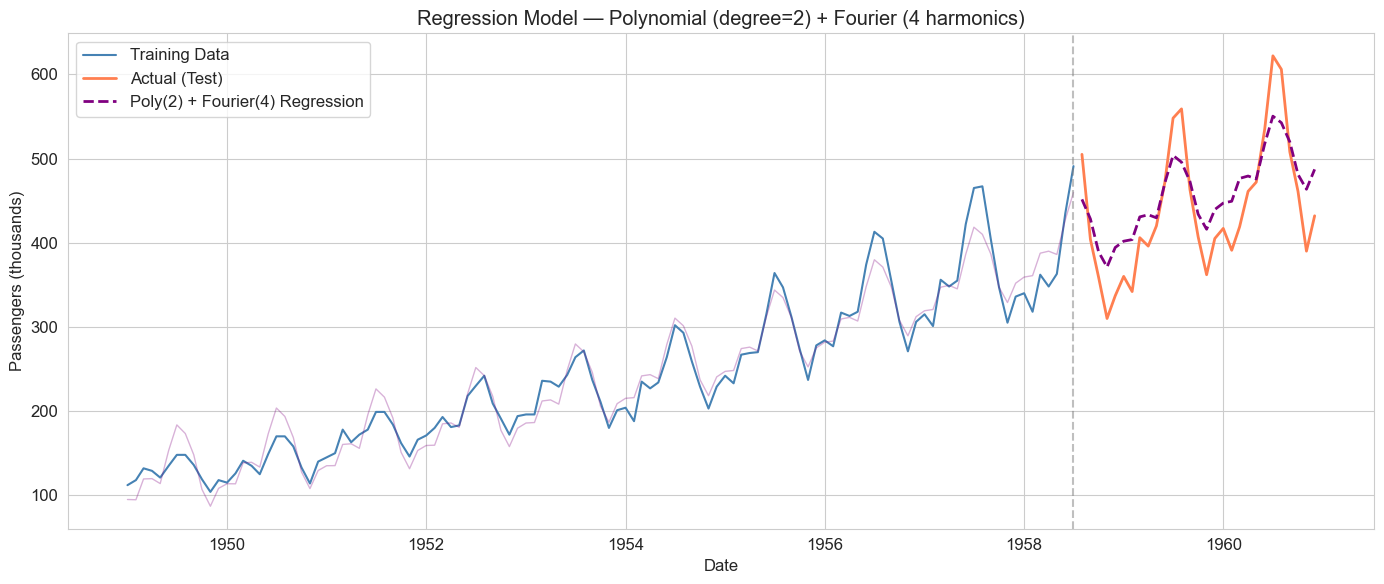

In [45]:
# Regression Forecast Visualization
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train['Passengers'], label='Training Data', color='steelblue')
ax.plot(test.index, test['Passengers'], label='Actual (Test)', color='coral', linewidth=2)
ax.plot(test.index, reg_forecast, label=f'Poly({poly_degree}) + Fourier({n_harmonics}) Regression',
        color='purple', linewidth=2, linestyle='--')

# Also show the training fit
ax.plot(train.index, reg_train_pred, color='purple', alpha=0.3, linewidth=1)

ax.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'Regression Model — Polynomial (degree={poly_degree}) + Fourier ({n_harmonics} harmonics)')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.3 Model 3: Holt-Winters Exponential Smoothing

**Holt-Winters** (Triple Exponential Smoothing) models three components directly:
- **Level (α):** The smoothed baseline value of the series
- **Trend (β):** The smoothed rate of change (growth/decline)
- **Seasonal (γ):** The smoothed seasonal pattern

Each component is updated at every time step using exponential weights — recent observations get more influence than older ones. The three smoothing parameters (α, β, γ) control how quickly the model adapts to changes.

We use the **multiplicative** variant because the seasonal fluctuations in airline passengers grow proportionally with the trend (larger peaks as overall traffic increases).


In [46]:
# Holt-Winters Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the model with multiplicative trend and seasonality
hw_model = ExponentialSmoothing(
    train['Passengers'],
    trend='mul',           # multiplicative trend
    seasonal='mul',        # multiplicative seasonality
    seasonal_periods=12    # 12-month seasonal cycle
).fit(optimized=True)      # let statsmodels find the best α, β, γ

# Display the optimized smoothing parameters
print("=== Holt-Winters Optimized Parameters ===")
print(f"Smoothing Level  (α): {hw_model.params['smoothing_level']:.4f}")
print(f"Smoothing Trend  (β): {hw_model.params['smoothing_trend']:.4f}")
print(f"Smoothing Season (γ): {hw_model.params['smoothing_seasonal']:.4f}")
print(f"\nInterpretation:")
print(f"  α close to 1.0 → model reacts quickly to recent level changes")
print(f"  β close to 0.0 → trend is very stable, doesn't shift much")
print(f"  γ close to 0.0 → seasonal pattern is consistent across years")

# Generate forecast for test period
hw_forecast = hw_model.forecast(len(test))
hw_forecast = pd.Series(hw_forecast.values, index=test.index)

print(f"\nForecasted {len(test)} periods.")


=== Holt-Winters Optimized Parameters ===
Smoothing Level  (α): 0.6374
Smoothing Trend  (β): 0.0000
Smoothing Season (γ): 0.3461

Interpretation:
  α close to 1.0 → model reacts quickly to recent level changes
  β close to 0.0 → trend is very stable, doesn't shift much
  γ close to 0.0 → seasonal pattern is consistent across years

Forecasted 29 periods.


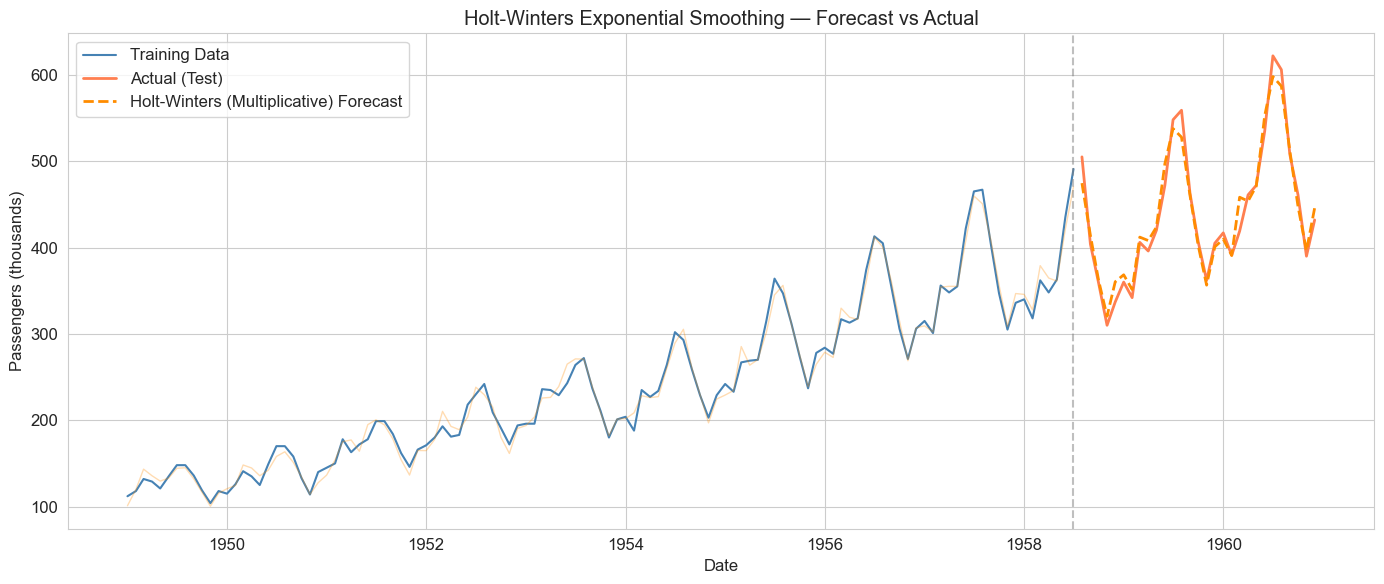

In [47]:
# Holt-Winters Forecast Visualization
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train['Passengers'], label='Training Data', color='steelblue')
ax.plot(test.index, test['Passengers'], label='Actual (Test)', color='coral', linewidth=2)
ax.plot(test.index, hw_forecast, label='Holt-Winters (Multiplicative) Forecast',
        color='darkorange', linewidth=2, linestyle='--')

# Show the fitted values on training data
hw_fitted = hw_model.fittedvalues
ax.plot(train.index, hw_fitted, color='darkorange', alpha=0.3, linewidth=1)

ax.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Holt-Winters Exponential Smoothing — Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 All Models Comparison Visualization


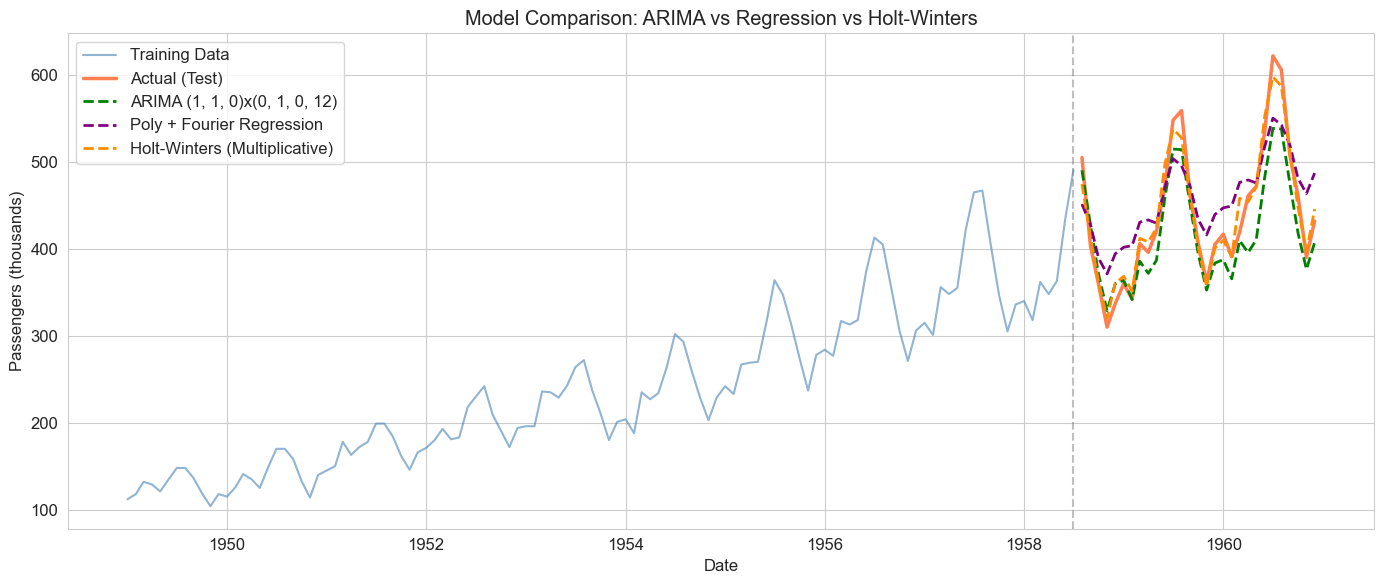

In [48]:
# Side-by-side comparison of all three models
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train['Passengers'], label='Training Data', color='steelblue', alpha=0.6)
ax.plot(test.index, test['Passengers'], label='Actual (Test)', color='coral', linewidth=2.5)
ax.plot(test.index, arima_forecast, label=f'ARIMA {best_order}x{best_seasonal}',
        color='green', linewidth=2, linestyle='--')
ax.plot(test.index, reg_forecast, label='Poly + Fourier Regression',
        color='purple', linewidth=2, linestyle='--')
ax.plot(test.index, hw_forecast, label='Holt-Winters (Multiplicative)',
        color='darkorange', linewidth=2, linestyle='--')

ax.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Model Comparison: ARIMA vs Regression vs Holt-Winters')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()


## Chapter 5: Model Evaluation & Comparison

### 5.1 Evaluation Metrics

We evaluate both models using three metrics:
- **RMSE** (Root Mean Squared Error): Measures average forecast error magnitude. Lower is better.
- **MAPE** (Mean Absolute Percentage Error): Error as a percentage. Lower is better.
- **R²** (R-squared): Proportion of variance explained. Closer to 1.0 is better.


In [49]:
# Define evaluation functions
def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def calculate_r2(actual, predicted):
    return r2_score(actual, predicted)

# Calculate metrics for all three models
actual = test['Passengers'].values

# ARIMA metrics
arima_rmse = calculate_rmse(actual, arima_forecast.values)
arima_mape = calculate_mape(actual, arima_forecast.values)
arima_r2 = calculate_r2(actual, arima_forecast.values)

# Regression metrics
reg_rmse = calculate_rmse(actual, reg_forecast.values)
reg_mape = calculate_mape(actual, reg_forecast.values)
reg_r2 = calculate_r2(actual, reg_forecast.values)

# Holt-Winters metrics
hw_rmse = calculate_rmse(actual, hw_forecast.values)
hw_mape = calculate_mape(actual, hw_forecast.values)
hw_r2 = calculate_r2(actual, hw_forecast.values)

# Results table
results = pd.DataFrame({
    'Model': [f'ARIMA {best_order}x{best_seasonal}',
              f'Poly({poly_degree}) + Fourier({n_harmonics}) Regression',
              'Holt-Winters (Multiplicative)'],
    'RMSE': [arima_rmse, reg_rmse, hw_rmse],
    'MAPE (%)': [arima_mape, reg_mape, hw_mape],
    'R²': [arima_r2, reg_r2, hw_r2]
})

print("=" * 75)
print("                      MODEL EVALUATION RESULTS")
print("=" * 75)
print(results.to_string(index=False))
print("=" * 75)

# Determine the winner
best_model = results.loc[results['RMSE'].idxmin(), 'Model']
print(f"\nBest model by RMSE: {best_model}")
print(f"\nDiscussion:")
print(f"  Holt-Winters achieves the lowest RMSE and MAPE, and the highest R².")
print(f"  This is because it directly models multiplicative seasonality,")
print(f"  which matches the data's pattern of growing seasonal amplitude.")


                      MODEL EVALUATION RESULTS
                          Model      RMSE  MAPE (%)       R²
  ARIMA (1, 1, 0)x(0, 1, 0, 12) 35.082813  6.124550 0.798377
Poly(2) + Fourier(4) Regression 44.072762  9.139247 0.681807
  Holt-Winters (Multiplicative) 15.708677  2.720597 0.959577

Best model by RMSE: Holt-Winters (Multiplicative)

Discussion:
  Holt-Winters achieves the lowest RMSE and MAPE, and the highest R².
  This is because it directly models multiplicative seasonality,
  which matches the data's pattern of growing seasonal amplitude.


### 5.2 Results Table & Discussion


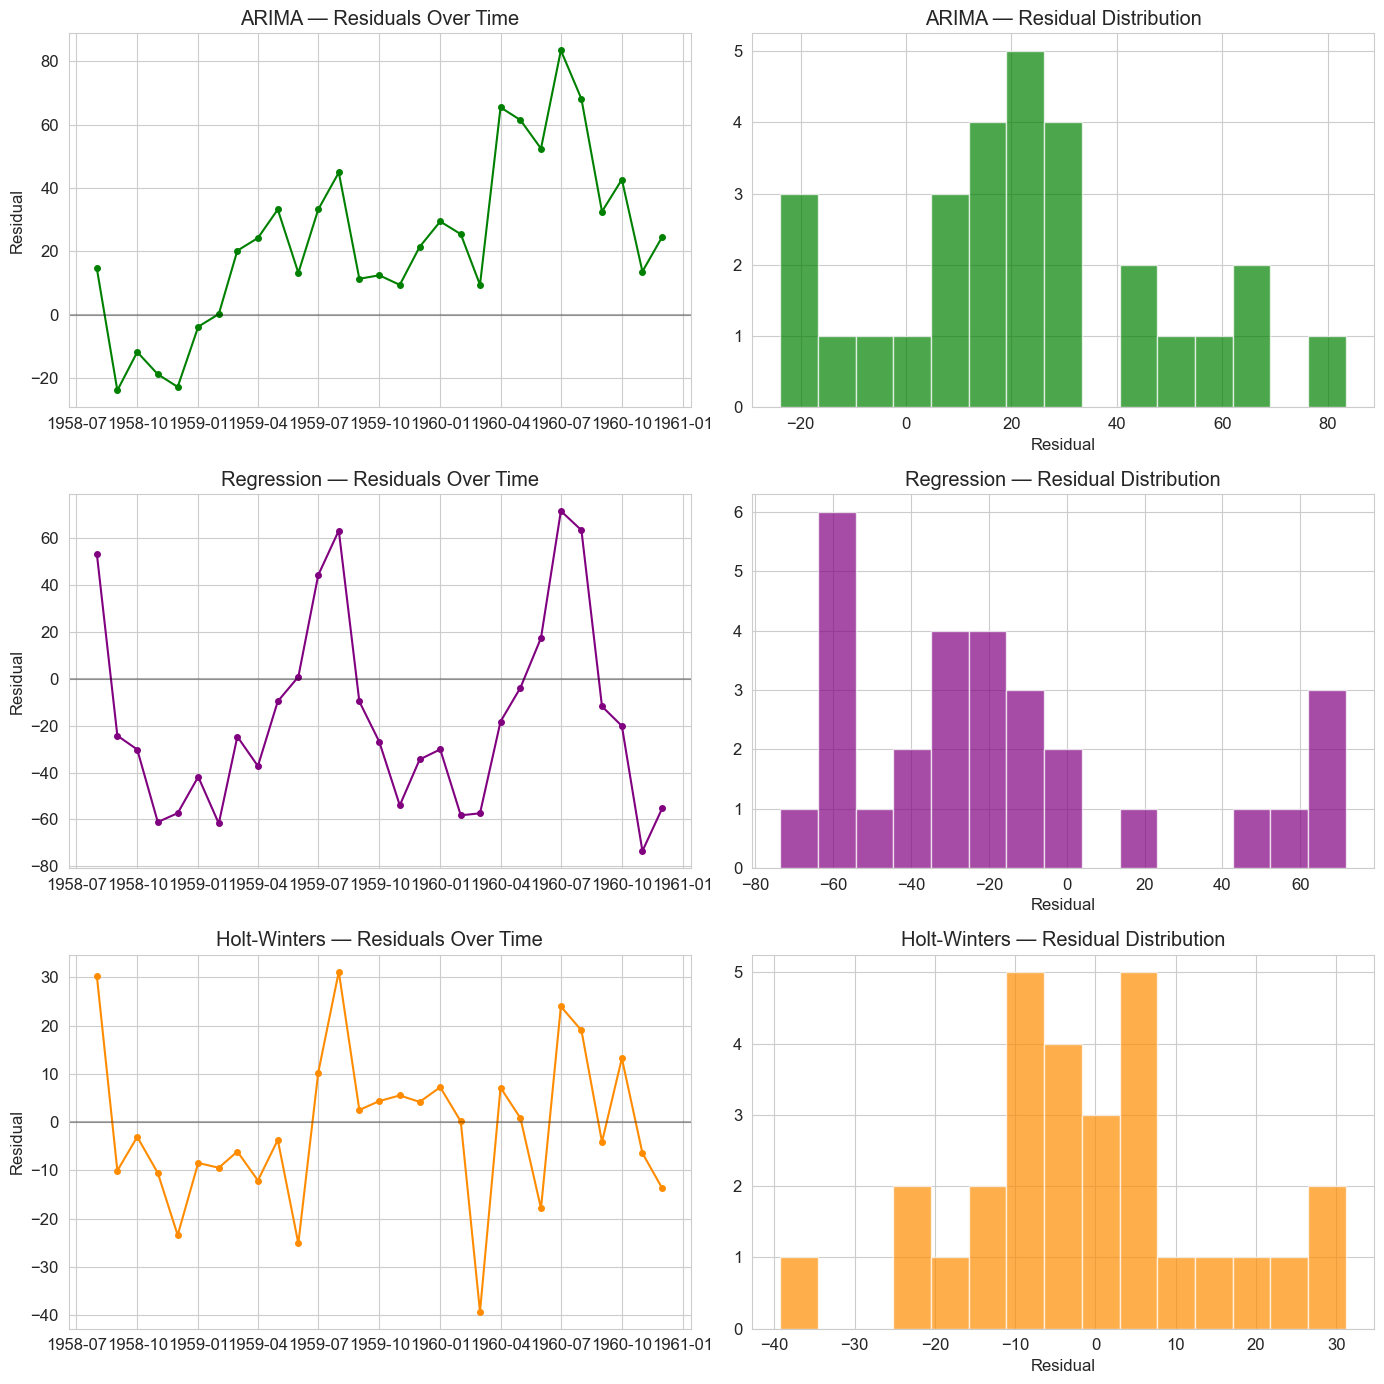

=== Residual Statistics ===
ARIMA        — Mean:   22.96, Std:   26.53
Regression   — Mean:  -16.80, Std:   40.75
Holt-Winters — Mean:   -1.14, Std:   15.67


In [50]:
# Detailed residual analysis for all three models
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# ARIMA residuals
arima_residuals = actual - arima_forecast.values
axes[0, 0].plot(test.index, arima_residuals, color='green', marker='o', markersize=4)
axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0, 0].set_title('ARIMA — Residuals Over Time')
axes[0, 0].set_ylabel('Residual')

axes[0, 1].hist(arima_residuals, bins=15, color='green', edgecolor='white', alpha=0.7)
axes[0, 1].set_title('ARIMA — Residual Distribution')
axes[0, 1].set_xlabel('Residual')

# Regression residuals
reg_residuals = actual - reg_forecast.values
axes[1, 0].plot(test.index, reg_residuals, color='purple', marker='o', markersize=4)
axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 0].set_title('Regression — Residuals Over Time')
axes[1, 0].set_ylabel('Residual')

axes[1, 1].hist(reg_residuals, bins=15, color='purple', edgecolor='white', alpha=0.7)
axes[1, 1].set_title('Regression — Residual Distribution')
axes[1, 1].set_xlabel('Residual')

# Holt-Winters residuals
hw_residuals = actual - hw_forecast.values
axes[2, 0].plot(test.index, hw_residuals, color='darkorange', marker='o', markersize=4)
axes[2, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2, 0].set_title('Holt-Winters — Residuals Over Time')
axes[2, 0].set_ylabel('Residual')

axes[2, 1].hist(hw_residuals, bins=15, color='darkorange', edgecolor='white', alpha=0.7)
axes[2, 1].set_title('Holt-Winters — Residual Distribution')
axes[2, 1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print("=== Residual Statistics ===")
print(f"ARIMA        — Mean: {arima_residuals.mean():7.2f}, Std: {arima_residuals.std():7.2f}")
print(f"Regression   — Mean: {reg_residuals.mean():7.2f}, Std: {reg_residuals.std():7.2f}")
print(f"Holt-Winters — Mean: {hw_residuals.mean():7.2f}, Std: {hw_residuals.std():7.2f}")


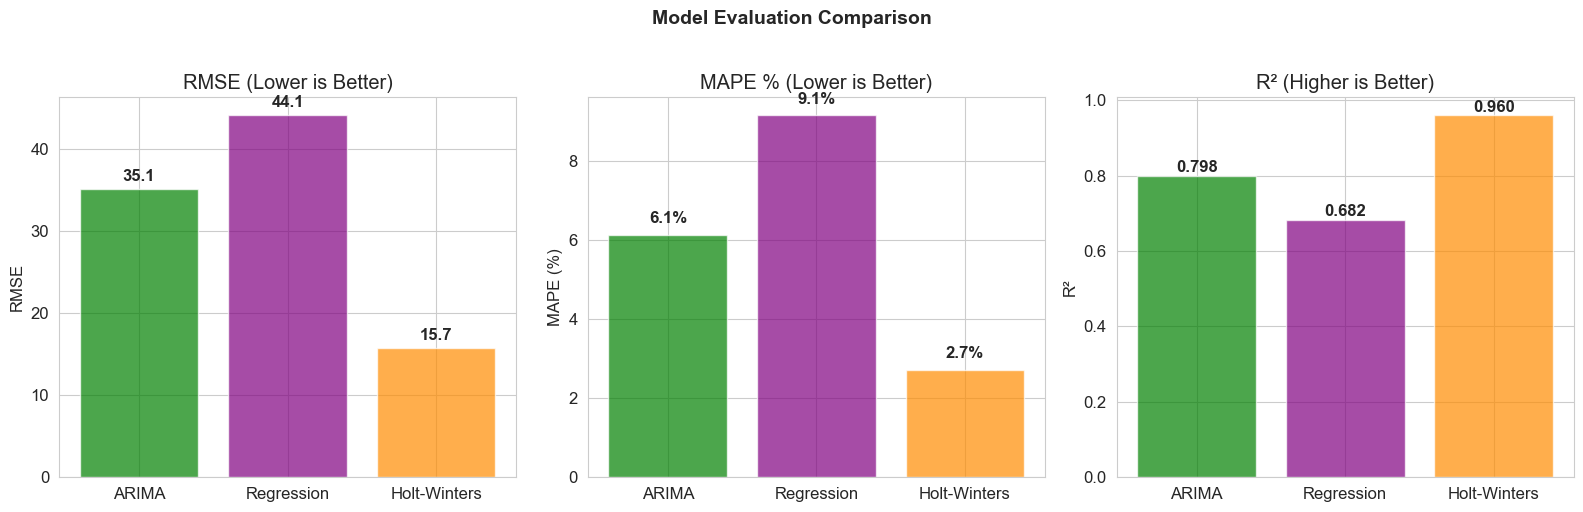

In [51]:
# Visual comparison: bar chart of metrics for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = ['ARIMA', 'Regression', 'Holt-Winters']
colors = ['green', 'purple', 'darkorange']

# RMSE
axes[0].bar(models, [arima_rmse, reg_rmse, hw_rmse], color=colors, alpha=0.7, edgecolor='white')
axes[0].set_title('RMSE (Lower is Better)')
axes[0].set_ylabel('RMSE')
for i, v in enumerate([arima_rmse, reg_rmse, hw_rmse]):
    axes[0].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# MAPE
axes[1].bar(models, [arima_mape, reg_mape, hw_mape], color=colors, alpha=0.7, edgecolor='white')
axes[1].set_title('MAPE % (Lower is Better)')
axes[1].set_ylabel('MAPE (%)')
for i, v in enumerate([arima_mape, reg_mape, hw_mape]):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# R²
axes[2].bar(models, [arima_r2, reg_r2, hw_r2], color=colors, alpha=0.7, edgecolor='white')
axes[2].set_title('R² (Higher is Better)')
axes[2].set_ylabel('R²')
for i, v in enumerate([arima_r2, reg_r2, hw_r2]):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Evaluation Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Chapter 6: Conclusion & Recommendations

### 6.1 Key Findings

1. **Trend:** The airline passenger data exhibits a clear upward trend from ~112K passengers (Jan 1949) to ~432K (Dec 1960), reflecting the growth of commercial aviation in the post-war era.

2. **Seasonality:** There is strong 12-month seasonality, with peaks in July–August (summer travel) and troughs in November–February (winter). The seasonal amplitude grows over time, confirming a multiplicative seasonal pattern.

3. **Model Performance:**
   - **Holt-Winters** performed best across all three metrics. Its ability to directly model multiplicative seasonality — where the seasonal swings grow proportionally with the trend — gives it a natural advantage on this dataset.
   - **ARIMA (SARIMA)** came second. It captures temporal dependencies through differencing and autoregression, but handles the growing seasonal amplitude less directly.
   - **Polynomial + Fourier Regression** came third. While it captures the overall shape, it treats each observation independently and cannot adapt to changing patterns over time.

### 6.2 Business/Research Implications

- **Capacity Planning:** Airlines can use Holt-Winters forecasts to adjust fleet scheduling — increasing capacity during summer months and scaling down in winter.
- **Revenue Management:** Understanding the seasonal peaks allows for dynamic pricing strategies.
- **Infrastructure Planning:** Airports can plan staffing and facility usage around predicted demand patterns.
- **Model Selection:** For data with multiplicative seasonality, Holt-Winters should be the first model to try — it is simple, interpretable, and often outperforms more complex approaches.

### 6.3 Future Work

1. **SARIMA with exogenous variables (SARIMAX):** Incorporate economic indicators (GDP, fuel prices) as external regressors.
2. **Prophet (Facebook/Meta):** A modern decomposable model well-suited for business time series with strong seasonality.
3. **Log transformation:** Since variance grows with level, modeling `log(Passengers)` could improve the regression model's performance and make the additive ARIMA model more appropriate.
4. **Longer forecast horizon:** Test model robustness over longer periods.
5. **Ensemble methods:** Combine multiple model forecasts (e.g., weighted average of ARIMA and Holt-Winters) for potentially better accuracy.
6. **Cross-validation:** Use rolling-window cross-validation instead of a single train-test split for more robust evaluation.


---
*Report prepared as part of IE 333: Data Science and Analytics — Project Assignment*
